# 2D Trilateration for Maritime Search and Rescue

## 1. Problem Formulation
In maritime navigation and search and rescue (SAR) operations, quickly locating a distressed vessel is critical. Often, ships lose their GPS navigation but continue to transmit a radio signal.

**The Case:** Three coastal stations (A, B, and C) with known coordinates intercept an SOS signal. By measuring the Time of Arrival (ToA) of the signal, the stations calculate their exact distance to the ship. Our goal is to build a mathematical model and algorithm to calculate the exact $(x, y)$ coordinates of the ship based on these three distances.

## 2. Assumptions and Constraints
To translate the real-world problem into a correct mathematical model, we introduce the following assumptions:
* **2D Plane:** For local rescue operations (in a small perimeter), we assume the surface is a Cartesian coordinate system, ignoring the Earth's curvature.
* **Ideal Data:** In this basic simulation, we assume that the radio signal has no interference and the calculated distances are perfectly accurate.

## 3. Mathematical Model (Analytic Geometry & Linear Algebra)

Each coastal station represents the center of a circle, and the calculated distance to the ship is its radius. The distressed vessel is located at the exact point where all three circles intersect.

The equation of a circle for station $i$ with coordinates $(x_i, y_i)$ and radius $r_i$ is:
$$(x - x_i)^2 + (y - y_i)^2 = r_i^2$$

We have a system of three non-linear equations. To solve it efficiently using linear algebra, we first expand the brackets:
$$x^2 - 2xx_i + x_i^2 + y^2 - 2yy_i + y_i^2 = r_i^2$$

To eliminate the non-linear terms ($x^2$ and $y^2$), we subtract Equation 2 from Equation 1, and Equation 3 from Equation 1. This gives us a system of two linear equations:
$$2(x_2 - x_1)x + 2(y_2 - y_1)y = (r_1^2 - r_2^2) - (x_1^2 - x_2^2) - (y_1^2 - y_2^2)$$
$$2(x_3 - x_1)x + 2(y_3 - y_1)y = (r_1^2 - r_3^2) - (x_1^2 - x_3^2) - (y_1^2 - y_3^2)$$

This system can be represented in matrix form $A \cdot X = B$ and solved algorithmically using standard computational libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set plot style for better visualization
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
def trilaterate_2d(p1, p2, p3, r1, r2, r3):
    """
    Calculates the intersection point of 3 circles using linear algebra.
    p1, p2, p3: Tuples containing (x, y) coordinates of the stations.
    r1, r2, r3: Radii (distances) from each station to the target.
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3

    # Setup Matrix A based on our mathematical model
    A = np.array([
        [2 * (x2 - x1), 2 * (y2 - y1)],
        [2 * (x3 - x1), 2 * (y3 - y1)]
    ])

    # Setup Vector B based on our mathematical model
    B = np.array([
        (r1**2 - r2**2) - (x1**2 - x2**2) - (y1**2 - y2**2),
        (r1**2 - r3**2) - (x1**2 - x3**2) - (y1**2 - y3**2)
    ])

    # Solve the linear system A * X = B
    try:
        ship_location = np.linalg.solve(A, B)
        return ship_location
    except np.linalg.LinAlgError:
        print("Error: The stations are collinear or the system has no unique solution.")
        return None

## 4. Simulation Setup and Execution
To test our algorithm, we will set up a simulated environment. We place three coastal stations at specific $(x, y)$ coordinates (in kilometers) and place a hypothetical ship in the ocean.

First, we calculate the exact Euclidean distances from the ship to the stations to simulate our "ideal" Time of Arrival (ToA) data. Then, we feed these distances into our linear algebra algorithm to see if it correctly finds the coordinates.

In [4]:
# Coast Guard Station coordinates (x, y) in kilometers
station_A = (0, 0)
station_B = (100, 0)
station_C = (50, 80)

# Simulated distress signal origin (The "true" location of the ship)
true_ship_location = (60, 40)

# Function to calculate Euclidean distance (simulating the ToA radius)
def calculate_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# Simulate the distances measured by each station
r_A = calculate_distance(station_A, true_ship_location)
r_B = calculate_distance(station_B, true_ship_location)
r_C = calculate_distance(station_C, true_ship_location)

print(f"Measured distances -> Station A: {r_A:.2f}km, Station B: {r_B:.2f}km, Station C: {r_C:.2f}km")

# Execute the algorithm
calculated_location = trilaterate_2d(station_A, station_B, station_C, r_A, r_B, r_C)

print(f"True Ship Location: {true_ship_location}")
print(f"Calculated Location: ({calculated_location[0]:.2f}, {calculated_location[1]:.2f})")

Measured distances -> Station A: 72.11km, Station B: 56.57km, Station C: 41.23km
True Ship Location: (60, 40)
Calculated Location: (60.00, 40.00)


## 5. Visualizing the Trilateration
To verify our mathematical model and the algorithm's result, we visualize the scenario using `matplotlib`. The plot displays the coastal stations, their respective range circles based on the ToA distances, and the calculated location of the distressed vessel.


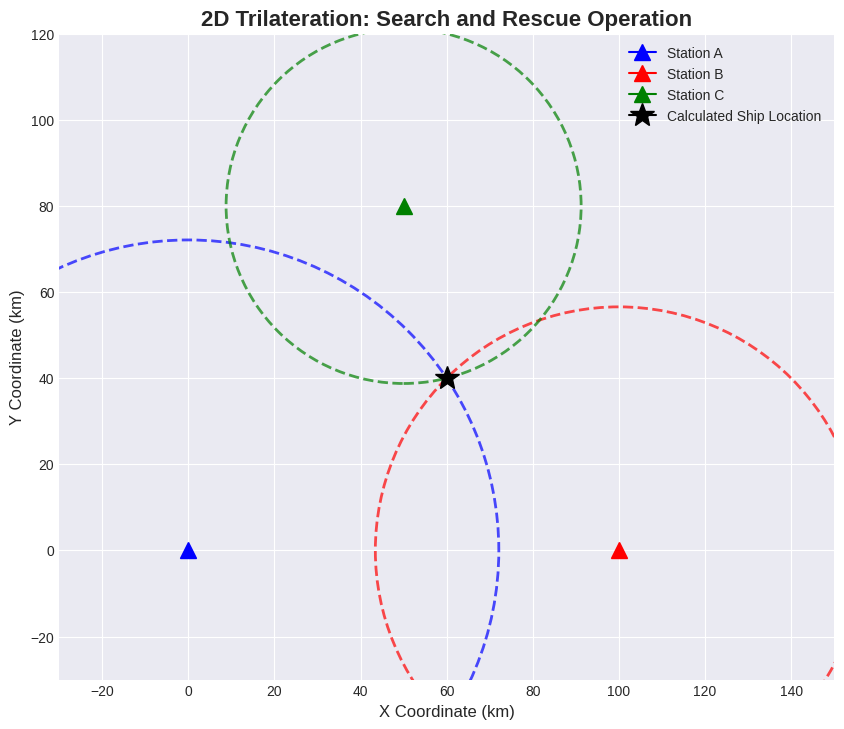

In [5]:
# Visualizing the Trilateration
fig, ax = plt.subplots(figsize=(10, 10))

# Define data for plotting
stations = {'A': station_A, 'B': station_B, 'C': station_C}
colors = {'A': 'blue', 'B': 'red', 'C': 'green'}
radii = {'A': r_A, 'B': r_B, 'C': r_C}

# Plot each station and its corresponding distance circle
for name, coord in stations.items():
    # Plot station point (represented as a triangle)
    ax.plot(coord[0], coord[1], marker='^', markersize=12, color=colors[name], label=f'Station {name}')

    # Draw the radius circle
    circle = plt.Circle(coord, radii[name], color=colors[name], fill=False, linestyle='--', linewidth=2, alpha=0.7)
    ax.add_patch(circle)

# Plot the calculated ship location (represented as a black star)
if calculated_location is not None:
    ax.plot(calculated_location[0], calculated_location[1], marker='*', markersize=18, color='black', label='Calculated Ship Location')

# Formatting the plot for better readability
ax.set_aspect('equal') # Crucial: ensures circles look like circles, not ellipses
ax.set_xlim(-30, 150)
ax.set_ylim(-30, 120)
ax.set_title('2D Trilateration: Search and Rescue Operation', fontsize=16, fontweight='bold')
ax.set_xlabel('X Coordinate (km)', fontsize=12)
ax.set_ylabel('Y Coordinate (km)', fontsize=12)
ax.legend(loc='upper right')

plt.show()
